Controladores de Tiempo Mínimo

In [121]:
# Import the packages needed for the examples included in this notebook
import numpy as np
import matplotlib.pyplot as plt
import control as ct

Definición del sistema contínuo

In [122]:
timepts = np.linspace(0, 10, 1000)
numc = 1
denc = [1, 1, 0]
sysc = ct.tf(numc, denc)
print(sysc)

<TransferFunction>: sys[108]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     1
  -------
  s^2 + s


Discretización a T

In [123]:
T = 0.5
sysd = ct.sample_system(sysc, T, method='zoh')
print(sysd)


<TransferFunction>: sys[108]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.5

    0.1065 z + 0.0902
  ----------------------
  z^2 - 1.607 z + 0.6065


Definición del controlador


In [124]:
numreg = [11.644 * x for x in [1, 0.736]]
denreg = [1, 0.914]
reg = ct.tf(numreg, denreg, T)
print(reg)
sysd1 = ct.feedback (sysd, reg)
print(sysd1)


<TransferFunction>: sys[110]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.5

  11.64 z + 8.57
  --------------
    z + 0.914
<TransferFunction>: sys[111]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.5

   0.1065 z^2 + 0.1876 z + 0.08245
  ----------------------------------
  z^3 + 0.5479 z^2 + 1.101 z + 1.327


Generar el lazo cerrado

Generar serie

In [125]:
sal_loop = ct.feedback(sysd, reg)
print(sal_loop)

<TransferFunction>: sys[112]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.5

   0.1065 z^2 + 0.1876 z + 0.08245
  ----------------------------------
  z^3 + 0.5479 z^2 + 1.101 z + 1.327


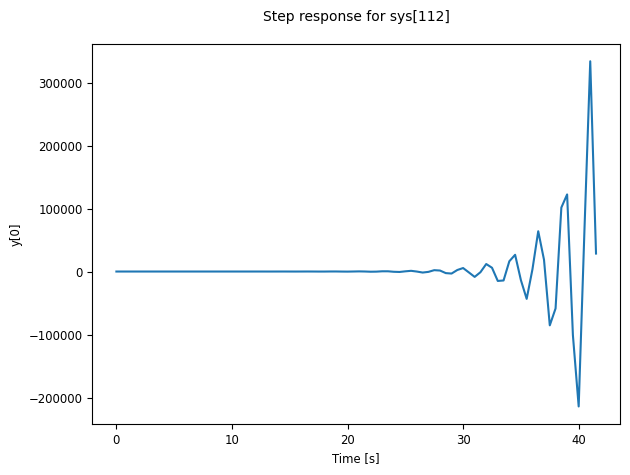

In [126]:
sal_loop_r = ct.step_response(sal_loop).plot()